# Contexte du projet


Une équipe médicale souhaite tester l’apport de l’intelligence artificielle dans **le diagnostic automatisé de la pneumonie à partir de radios thoraciques.** Elle a besoin d’un prototype fonctionnel (Proof of Concept) permettant de démontrer la faisabilité d’**un système de classification binaire d’images médicales**.

>Le problème posé consiste à réutiliser un modèle de vision par ordinateur **pré-entraîné (type CNN)** pour l’adapter au contexte médical, sans repartir d’un entraînement complet.

> Dans une logique de mise en production à moyen terme, il est également attendu de documenter et tracer les expérimentations réalisées. L’usage de **MLflow** est proposé pour initier cette démarche, en assurant le suivi des performances, la traçabilité des essais et la gestion des versions de modèles dans une perspective MLOps.

# Modalités d'évaluation
Évaluation individuelle à partir du livrable (notebook). 
Le barème porte sur 
- **la qualité de la démarche (pertinence des choix, rigueur des étapes, clarté des explications),** 
- **la bonne compréhension du transfert learning,**
- **et l’initiation à MLflow (usage basique)**.

# Livrables
Un **lien GitHub** contenant les travaux réalisés, notamment un notebook complet, structuré, lisible et commenté, incluant :
- Préparation et exploration du dataset
- Mise en place du modèle pré-entraîné et adaptation
- Entraînement, évaluation (matrice de confusion, courbes, métriques etc...)
- Suivi des expériences via MLflow
- Le dépôt du code sur GitHub avec les travaux réalisé (notebook) avec un README synthétique

# Critères de performance
- Le notebook couvre toutes **les étapes clés de la démarche** (pré-traitement, modélisation, évaluation)
- Les **choix techniques sont justifiés** avec clarté et cohérence
- Le **modèle est adapté** de manière correcte à la tâche de classification binaire
- L’**évaluation du modèle est rigoureuse** (métriques pertinentes, commentaires clairs)
- La première utilisation de **MLflow est fonctionnelle et comprise** (log simple de paramètres ou de métriques)
- Le **code est structuré, commenté, exécutable**
- *La performance du modèle n'est pas un critère de performances, seul compte la démarche, la compréhension et donc la clarté des notes dans le le notebook*

----

# 1. Chargement des bibliothèques nécessaires

 - Création manuelle d'un environnment virtuel `python -m venv .venv` et l'activer ` .\.venv\Scripts\Activate.ps1` (sous windows os)
 - Installer les bibliothèques `pip install -r requirements.txt` 
 - choisir le dossier .venv dans "Python: Select interpreter" (Command Palette)
 (venv contenant python 3.10 compatible avec tensorflow)
 - installer ipykernel pour executer

In [10]:
import os  # os pour manipuler des dossiers et fichiers
import numpy as np # np pour manipuler des vecteurs et matrices
import pandas as pd # pd pour traiter des dataframe et visualiser des figures
import seaborn as sns # pd pour visualiser des figures

import mlflow #  pour documenter et tracer les expérimentations réalisées.
import mlflow.tensorflow
# DL Lib
import tensorflow as tf 

from tensorflow.keras.layers import Input,Dense, Dropout, GlobalAveragePooling2D,Concatenate
from tensorflow.keras.applications import DenseNet121, ResNet50V2
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt  #  pour visualiser des figures
from tensorflow.keras.utils import plot_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import roc_curve,roc_auc_score,auc, confusion_matrix, classification_report,accuracy_score # pd pour évaluer le modèle
import cv2


# 2. Préparation et exploration du dataset

[[[ 24  24  24]
  [ 20  20  20]
  [ 19  19  19]
  [ 17  17  17]
  [ 17  17  17]
  [ 28  28  28]
  [ 56  56  56]
  [ 58  58  58]
  [ 64  64  64]
  [ 65  65  65]
  [ 72  72  72]
  [ 74  74  74]
  [ 80  80  80]
  [ 86  86  86]
  [ 90  90  90]
  [ 90  90  90]
  [ 92  92  92]
  [ 91  91  91]
  [ 99  99  99]
  [ 98  98  98]
  [100 100 100]
  [ 99  99  99]
  [102 102 102]
  [102 102 102]
  [107 107 107]
  [107 107 107]
  [110 110 110]
  [115 115 115]
  [111 111 111]
  [134 134 134]
  ...
  [ 84  84  84]
  [ 88  88  88]
  [ 88  88  88]
  [ 93  93  93]
  [ 91  91  91]
  [ 93  93  93]
  [ 98  98  98]
  [ 98  98  98]
  [ 98  98  98]
  [ 99  99  99]
  [100 100 100]
  [115 115 115]
  [147 147 147]
  [168 168 168]
  [155 155 155]
  [140 140 140]
  [138 138 138]
  [133 133 133]
  [133 133 133]
  [138 138 138]
  [152 152 152]
  [166 166 166]
  [138 138 138]
  [ 96  96  96]
  [ 96  96  96]
  [ 94  94  94]
  [ 95  95  95]
  [ 95  95  95]
  [ 94  94  94]
  [ 95  95  95]]

 [[ 22  22  22]
  [ 22  22  22]


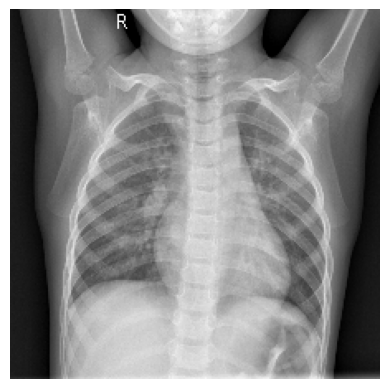

Shape (dimensions)    : (224, 224, 3)
Type des valeurs      : uint8


In [2]:
# On charge une image depuis le répertoire data/
img = cv2.imread("../data/train/NORMAL/IM-0115-0001.jpeg", cv2.IMREAD_GRAYSCALE)
# Convert to 3 channels
img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB) # Now shape is (H, W, 3)
# Resize to model input size (e.g., 224x224)
resized_img = cv2.resize(img_rgb, (224, 224))
# Observer l'image sous forme de matrice
print(resized_img)

# Visualisation de l'image
plt.imshow(resized_img, cmap="gray")
plt.axis("off")
plt.show()

# Inspection des métadonnées de l'image
print(f"Shape (dimensions)    : {resized_img.shape}")
print(f"Type des valeurs      : {resized_img.dtype}")

## Chargement des données

In [28]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# Create ImageDataGenerator instances & normalization
train_datagen = ImageDataGenerator(rescale=1./255)  
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load datasets
train_generator = train_datagen.flow_from_directory(
    '../data/train',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb'  # Converts grayscale to 3 channels automatically
)

val_generator = val_datagen.flow_from_directory(
    '../data/val',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb'
)

test_generator = test_datagen.flow_from_directory(
    '../data/test',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb',
    shuffle=False  # Usually better for evaluation
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


## Vérification

In [ ]:
from utils.functions_data import generator_to_numpy
# Convert generators to NumPy arrays
X_train, y_train = generator_to_numpy(train_generator)
X_val, y_val = generator_to_numpy(val_generator)
X_test, y_test = generator_to_numpy(test_generator)

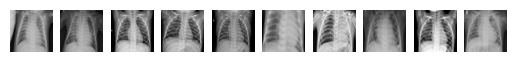

In [7]:
# Vérification des données préparées
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(X_train[i], cmap="grey")
   
    plt.axis("off")

plt.show()

# 3. Modélisation & compilation (ensemble learning)

- Pour un transfer learning : choisir selon les performances le modèle de base pré-entrainé (DenseNet121, ResNet50v2 ...) sur les données ImageNet
- Pour un ensemble learning : combiner plusieurs modèles ensemble

In [50]:
input_tensor1 = Input(shape=(224,224,3))
input_tensor2 = Input(shape=(224,224,3))

base_model_densenet = DenseNet121(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model_resnet = ResNet50V2(weights='imagenet', include_top=False, input_shape=(224,224,3))

base_model_densenet.trainable = False
base_model_resnet.trainable = False

feat1 = base_model_densenet(input_tensor1)
feat2 = base_model_resnet(input_tensor2)

feat1 = GlobalAveragePooling2D()(feat1)
feat2 = GlobalAveragePooling2D()(feat2)

concat = Concatenate()([feat1, feat2])
x = Dense(256, activation='relu')(concat)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model_ensemble = Model(inputs=[input_tensor1, input_tensor2], outputs=output)
model_ensemble.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
    


---

# 4. Mlflow Auto-tracking 

In [25]:
mlflow.tensorflow.autolog()
mlflow.set_experiment("TransferLearning-EnsembleLearning_CNN")

2025/05/26 12:43:41 INFO mlflow.tracking.fluent: Experiment with name 'TransferLearning-EnsembleLearning_CNN' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///c:/Users/User/Desktop/DL_transfer_CNN_pneumonia/notebooks/mlruns/545825517160109166', creation_time=1748256221490, experiment_id='545825517160109166', last_update_time=1748256221490, lifecycle_stage='active', name='TransferLearning-EnsembleLearning_CNN', tags={}>

## Fitting

In [51]:
history_ensemble = model_ensemble.fit(
    [X_train, X_train], y_train,
    validation_data=([X_val, X_val], y_val),
    batch_size=32,
    epochs=5

)

2025/05/26 14:26:51 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '79c671b6b228431e98fe0e0014bd001a', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current tensorflow workflow
2025/05/26 14:26:51 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'list'>. Dataset logging skipped.
2025/05/26 14:26:51 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'list' object has no attribute 'flatten'


Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8644 - loss: 0.3109

163/163 ━━━━━━━━━━━━━━━━━━━━ 1060s 6s/step - accuracy: 0.8647 - loss: 0.3103 - val_accuracy: 0.8750 - val_loss: 0.3699
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1176s 7s/step - accuracy: 0.9545 - loss: 0.1207 - val_accuracy: 0.6875 - val_loss: 0.6539
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9640 - loss: 0.0990

163/163 ━━━━━━━━━━━━━━━━━━━━ 1039s 6s/step - accuracy: 0.9640 - loss: 0.0989 - val_accuracy: 0.8125 - val_loss: 0.3564
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9760 - loss: 0.0758

163/163 ━━━━━━━━━━━━━━━━━━━━ 1049s 6s/step - accuracy: 0.9760 - loss: 0.0758 - val_accuracy: 0.8750 - val_loss: 0.3177
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9760 - loss: 0.0671

163/163 ━━━━━━━━━━━━━━━━━━━━ 899s 6s/step - accuracy: 0.9760 - loss: 0.0671 - val_accuracy: 0.8750 - val_loss: 0.2950


2025/05/26 15:53:59 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: Cannot log input example or model signature for input with type <class 'list'>. TensorFlow Keras autologging can only log input examples and model signatures for the following input types: numpy.ndarray, dict[string -> numpy.ndarray], tensorflow.keras.utils.Sequence, and tensorflow.data.Dataset (TensorFlow >= 2.1.0 required)
2025/05/26 15:53:59 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/05/26 15:54:41 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


## Logging

In [62]:
with mlflow.start_run(run_name="run-ensemble-dual_input"):
     # log the model
    mlflow.keras.log_model(model_ensemble,"model_ensemble_dual_input")
    mlflow.tensorflow.save_model(model_ensemble,"../models/my_model_ensemble")
    
    

2025/05/26 16:45:23 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2025/05/26 16:45:48 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/05/26 16:45:48 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


In [58]:
model_ensemble.save('../models/my_model_ensemble_dual_input.keras')

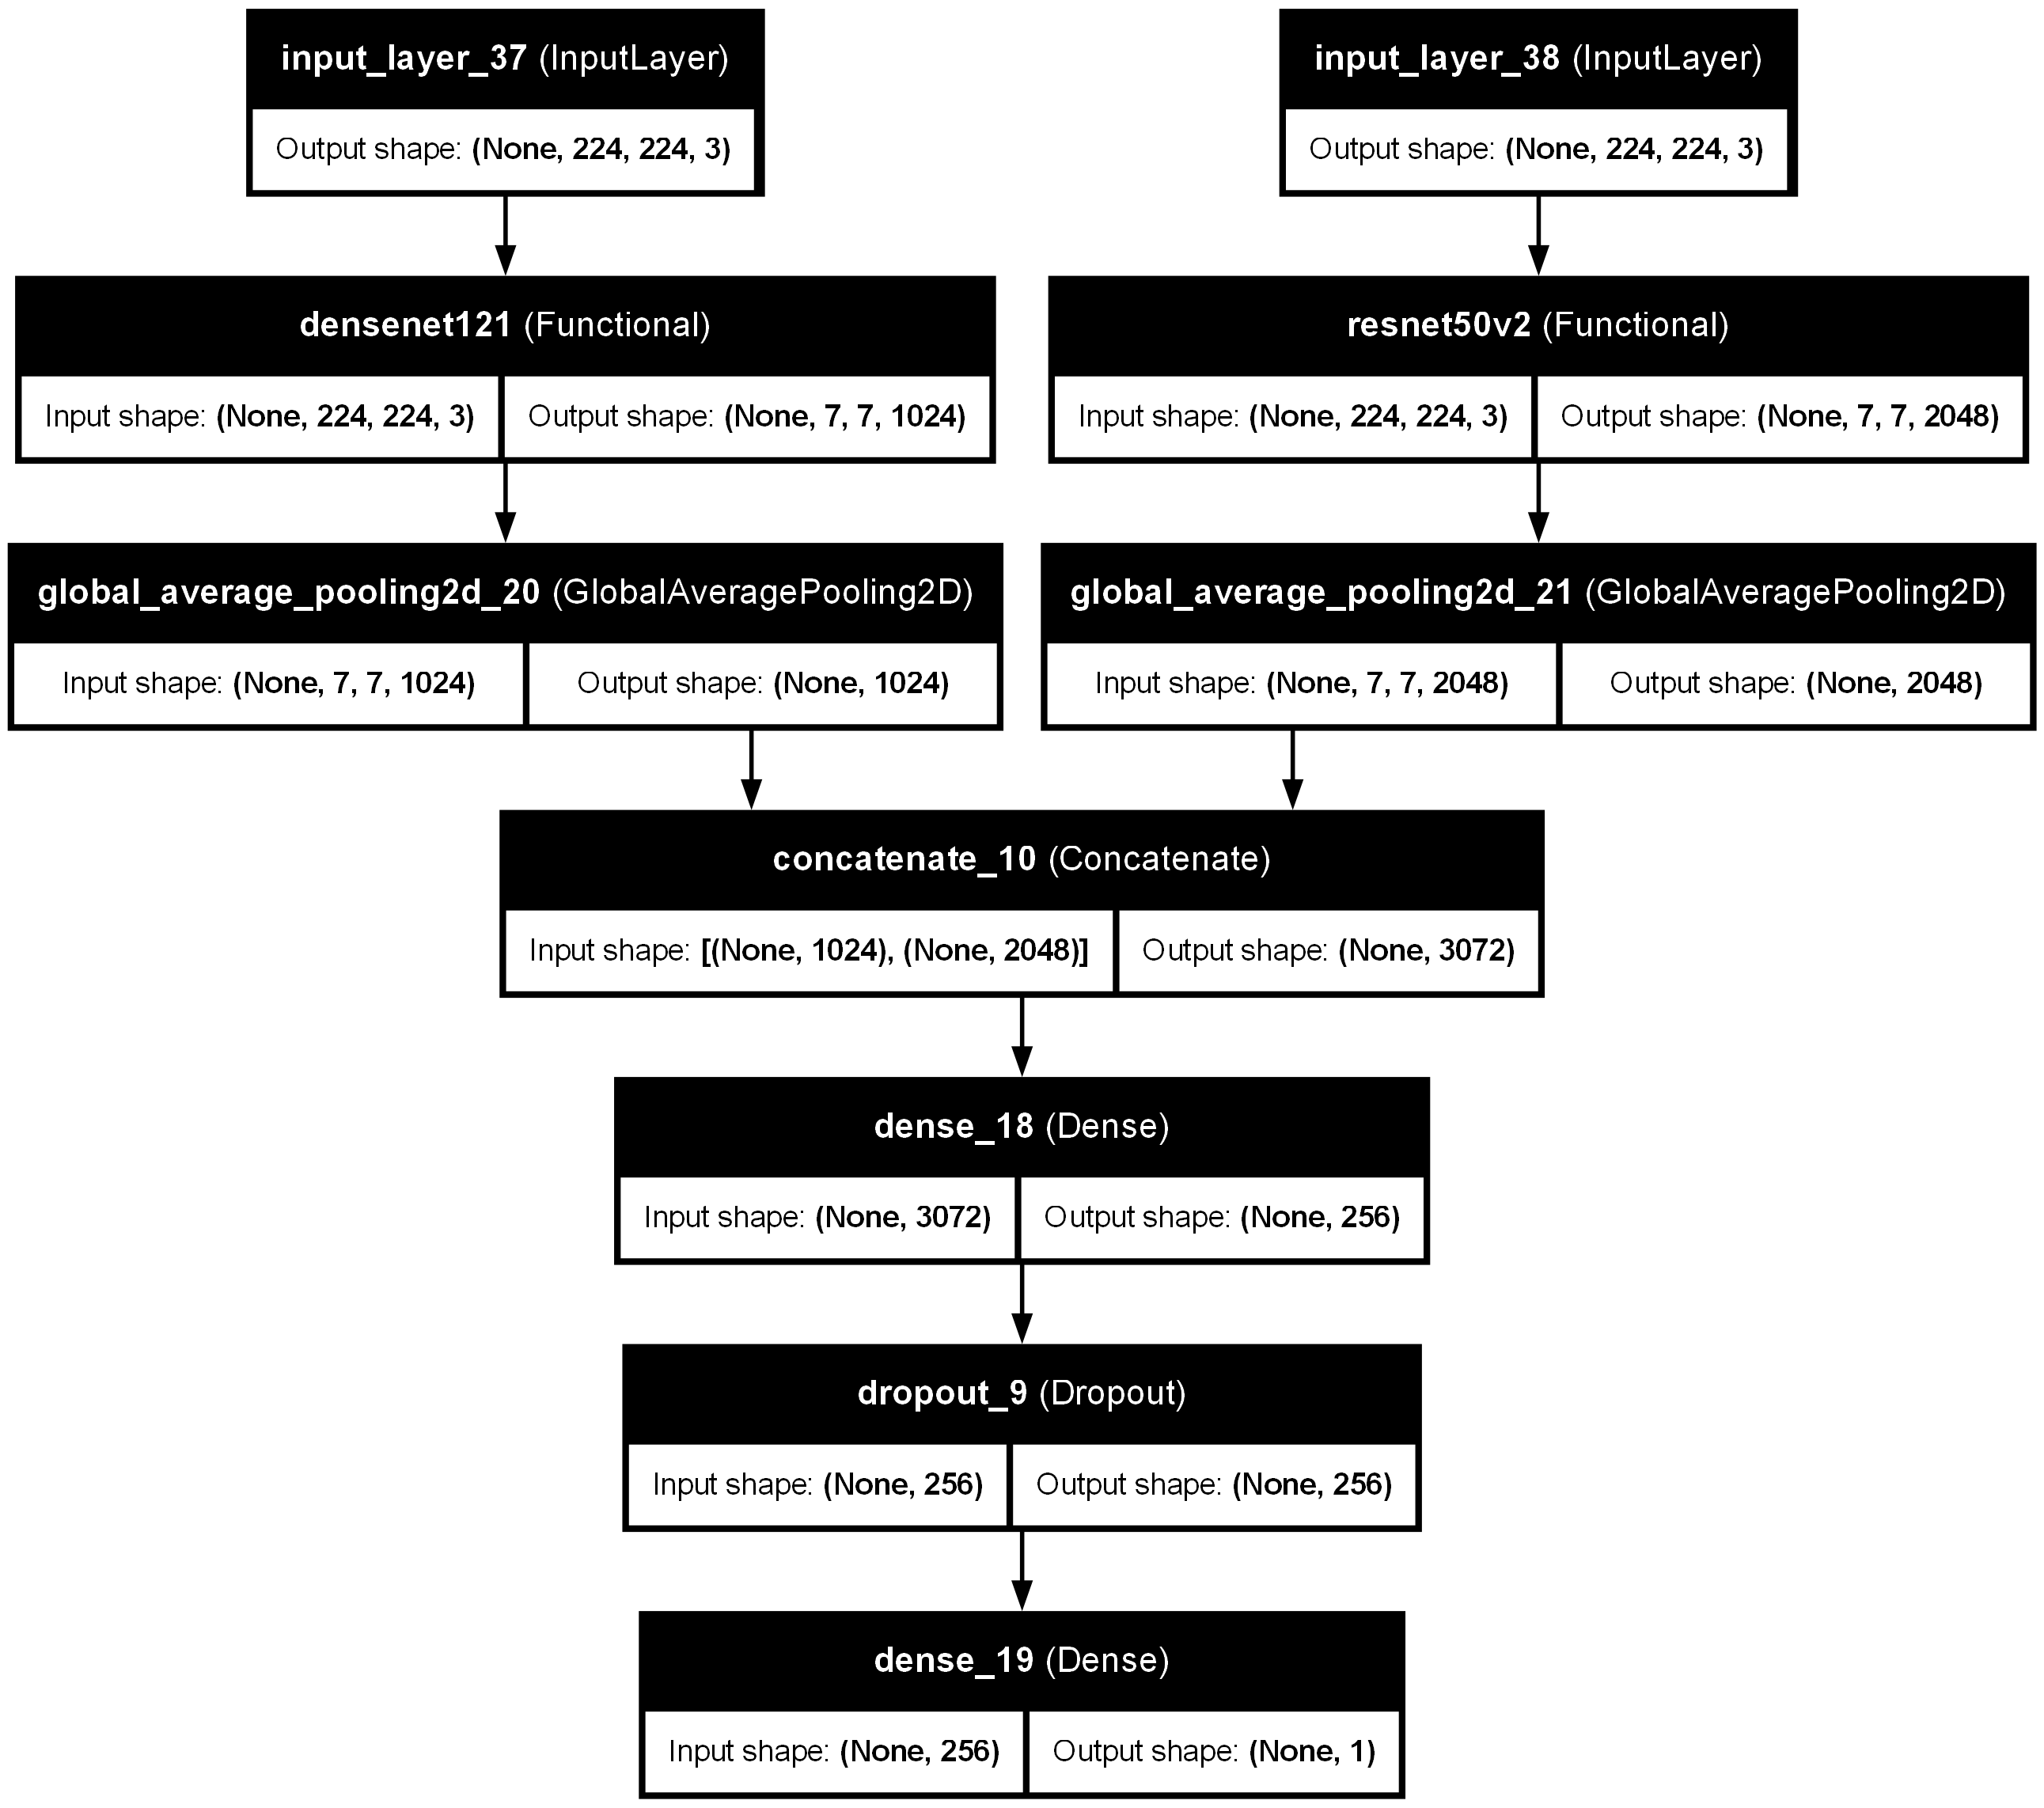

In [64]:
plot_model(model_ensemble, to_file='../figures/ensemble/model_ensemble_architecture.png', show_shapes=True, show_layer_names=True)


# 5. Evaluation

In [65]:
runs = mlflow.search_runs()
runs

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.accuracy,metrics.loss,metrics.val_loss,metrics.validation_loss,...,params.shuffle,params.opt_loss_scale_factor,params.steps_per_epoch,tags.mlflow.user,tags.mlflow.log-model.history,tags.mlflow.source.name,tags.mlflow.source.type,tags.mlflow.runName,tags.mlflow.autologging,tags.mlflow.latest_checkpoint_artifact
0,e2f006055bdf41839ea867af379a436b,545825517160109166,FINISHED,file:///c:/Users/User/Desktop/DL_transfer_CNN_...,2025-05-26 14:45:22.941000+00:00,2025-05-26 14:46:12.551000+00:00,NaN,NaN,NaN,NaN,...,None,None,None,User,"[{""run_id"": ""e2f006055bdf41839ea867af379a436b""...",c:\Users\User\Desktop\DL_transfer_CNN_pneumoni...,LOCAL,run-ensemble-dual_input,None,None
1,bca2e397bdcf47f8aae6318b36e8d387,545825517160109166,FAILED,file:///c:/Users/User/Desktop/DL_transfer_CNN_...,2025-05-26 14:43:43.755000+00:00,2025-05-26 14:44:06.116000+00:00,NaN,NaN,NaN,NaN,...,None,None,None,User,"[{""run_id"": ""bca2e397bdcf47f8aae6318b36e8d387""...",c:\Users\User\Desktop\DL_transfer_CNN_pneumoni...,LOCAL,run-ensemble-dual_input,None,None
2,0a260abcd5bc4444971b2909f33b3075,545825517160109166,FAILED,file:///c:/Users/User/Desktop/DL_transfer_CNN_...,2025-05-26 14:39:53.678000+00:00,2025-05-26 14:40:17.675000+00:00,NaN,NaN,NaN,NaN,...,None,None,None,User,"[{""run_id"": ""0a260abcd5bc4444971b2909f33b3075""...",c:\Users\User\Desktop\DL_transfer_CNN_pneumoni...,LOCAL,run-ensemble-dual_input,None,None
3,20d93565cc3543eda7f48dcff939c759,545825517160109166,FAILED,file:///c:/Users/User/Desktop/DL_transfer_CNN_...,2025-05-26 14:19:56.185000+00:00,2025-05-26 14:20:17.731000+00:00,NaN,NaN,NaN,NaN,...,None,None,None,User,"[{""run_id"": ""20d93565cc3543eda7f48dcff939c759""...",c:\Users\User\Desktop\DL_transfer_CNN_pneumoni...,LOCAL,run-ensemble-dual_input,None,None
4,bbdcb6fbe7874e829c63c4584bec60d3,545825517160109166,FAILED,file:///c:/Users/User/Desktop/DL_transfer_CNN_...,2025-05-26 14:19:10.739000+00:00,2025-05-26 14:19:31.977000+00:00,NaN,NaN,NaN,NaN,...,None,None,None,User,"[{""run_id"": ""bbdcb6fbe7874e829c63c4584bec60d3""...",c:\Users\User\Desktop\DL_transfer_CNN_pneumoni...,LOCAL,run-ensemble-dual_input,None,None
5,35054860411f41e988a53bbc72b701c1,545825517160109166,FINISHED,file:///c:/Users/User/Desktop/DL_transfer_CNN_...,2025-05-26 13:55:25.953000+00:00,2025-05-26 13:56:12.357000+00:00,NaN,NaN,NaN,NaN,...,None,None,None,User,"[{""run_id"": ""35054860411f41e988a53bbc72b701c1""...",c:\Users\User\Desktop\DL_transfer_CNN_pneumoni...,LOCAL,run-ensemble-dual_input,None,None
6,79c671b6b228431e98fe0e0014bd001a,545825517160109166,FINISHED,file:///c:/Users/User/Desktop/DL_transfer_CNN_...,2025-05-26 12:26:51.249000+00:00,2025-05-26 13:54:42.172000+00:00,0.973543,0.071258,0.295019,0.295019,...,True,None,None,User,"[{""run_id"": ""79c671b6b228431e98fe0e0014bd001a""...",c:\Users\User\Desktop\DL_transfer_CNN_pneumoni...,LOCAL,kindly-hawk-949,tensorflow,checkpoints/latest_checkpoint.h5
7,edcf4cc51b0548519125308a8f5e2d3f,545825517160109166,FAILED,file:///c:/Users/User/Desktop/DL_transfer_CNN_...,2025-05-26 12:24:41.922000+00:00,2025-05-26 12:24:42.161000+00:00,NaN,NaN,NaN,NaN,...,True,None,None,User,None,c:\Users\User\Desktop\DL_transfer_CNN_pneumoni...,LOCAL,stylish-bee-428,tensorflow,None
8,9294396b25b744e287b1b936f31fccd1,545825517160109166,FAILED,file:///c:/Users/User/Desktop/DL_transfer_CNN_...,2025-05-26 12:17:20.880000+00:00,2025-05-26 12:18:04.497000+00:00,NaN,NaN,NaN,NaN,...,True,None,None,User,None,c:\Users\User\Desktop\DL_transfer_CNN_pneumoni...,LOCAL,carefree-newt-654,tensorflow,None
9,875c0c26b1c54279862f511486abbf79,545825517160109166,FAILED,file:///c:/Users/User/Desktop/DL_transfer_CNN_...,2025-05-26 12:11:01.342000+00:00,2025-05-26 12:11:18.420000+00:00,NaN,NaN,NaN,NaN,...,True,None,None,User,None,c:\Users\User\Desktop\DL_transfer_CNN_pneumoni...,LOCAL,run-ensemble-dual_input,None,None


20/20 ━━━━━━━━━━━━━━━━━━━━ 131s 6s/step
Confusion Matrix:
 [[140  94]
 [  6 384]]


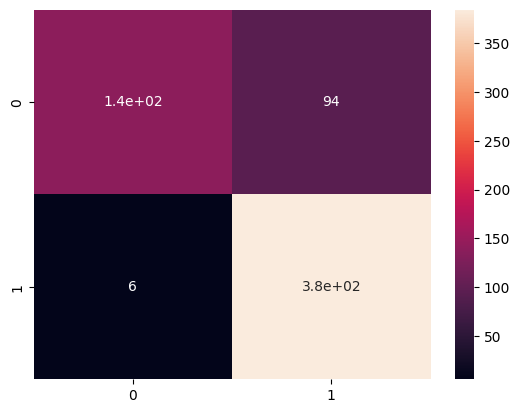

Classification Report:

              precision    recall  f1-score   support

      Normal       0.96      0.60      0.74       234
   Pneumonia       0.80      0.98      0.88       390

    accuracy                           0.84       624
   macro avg       0.88      0.79      0.81       624
weighted avg       0.86      0.84      0.83       624



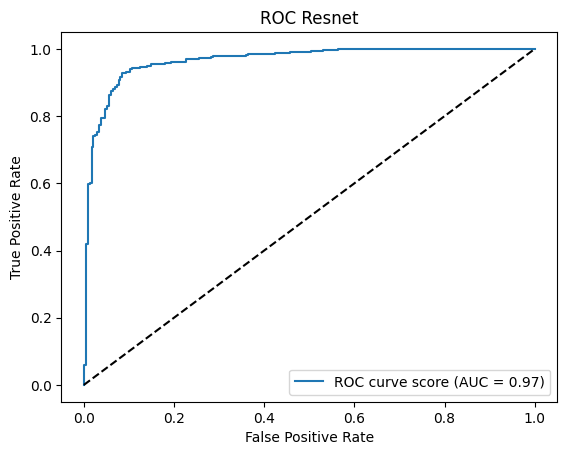

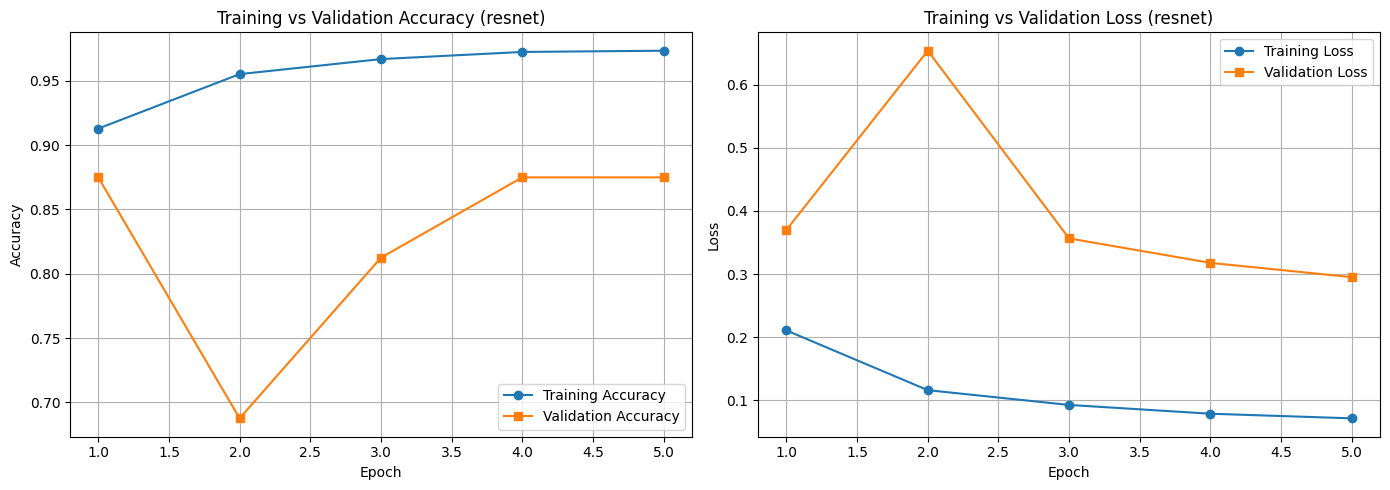

<Figure size 640x480 with 0 Axes>

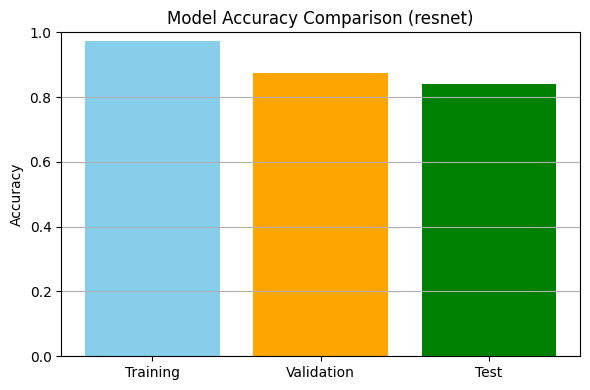

In [ ]:
run_name="run-ensemble-dual_input"
# Get predictions on test data


y_pred_prob = model_ensemble.predict([X_test,X_test])



y_pred = (y_pred_prob > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm,annot=True)
plt.savefig('../figures/ensemble/confusion_matrix_ensemble.png')
print("Confusion Matrix:\n", cm)
plt.show()
mlflow.log_artifact('../figures/ensemble/confusion_matrix_ensemble.png')

# Classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Pneumonia']))

# ROC score
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve score (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Resnet')
plt.legend(loc='lower right')
plt.savefig('../figures/ensemble/ROC_ensemble.png')

plt.show()
mlflow.log_artifact('../figures/ensemble/ROC_ensemble.png')


# Extract metrics
train_acc = history_ensemble.history['accuracy']
val_acc = history_ensemble.history['val_accuracy']
train_loss = history_ensemble.history['loss']
val_loss = history_ensemble.history['val_loss']
epochs = range(1, len(train_acc) + 1)

# Create subplots
plt.figure(figsize=(14, 5))

# Accuracy subplot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, label='Training Accuracy', marker='o')
plt.plot(epochs, val_acc, label='Validation Accuracy', marker='s')
plt.title('Training vs Validation Accuracy (resnet)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss subplot
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, label='Training Loss', marker='o')
plt.plot(epochs, val_loss, label='Validation Loss', marker='s')
plt.title('Training vs Validation Loss (resnet)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
plt.savefig("../figures/ensemble/training_val_curves.png")
mlflow.log_artifact("../figures/ensemble/training_val_curves_ensemble.png")


# Model accuracy train vs val vs test
train_acc = history_ensemble.history['accuracy'][-1]        # Final training accuracy
val_acc = history_ensemble.history['val_accuracy'][-1]      # Final validation accuracy
test_loss, test_acc = model_ensemble.evaluate([X_test,X_test], y_test, verbose=0)
accuracies = [train_acc, val_acc, test_acc]
labels = ['Training', 'Validation', 'Test']

plt.figure(figsize=(6, 4))
plt.bar(labels, accuracies, color=['skyblue', 'orange', 'green'])
plt.ylim(0, 1)  # Accuracy ranges from 0 to 1
plt.title('Model Accuracy Comparison (resnet)')
plt.ylabel('Accuracy')
plt.grid(axis='y')
plt.tight_layout()
plt.savefig("../figures/ensemble/accuracy_comparison.png")
plt.show()
mlflow.log_artifact("../figures/ensemble/accuracy_comparison.png")

# 6. Comparaison des modèles

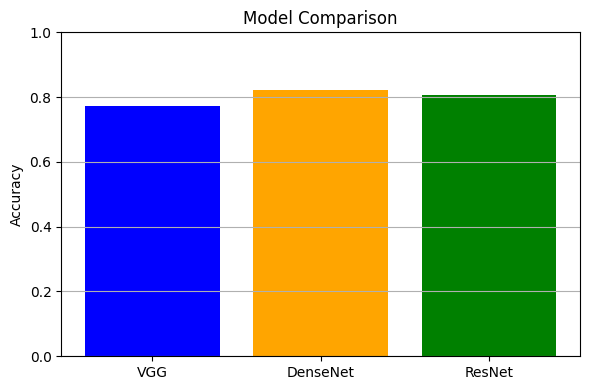

In [ ]:
models = []
test_accuracies =[]
for model in models:
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    test_accuracies.append(test_acc)
labels = ["VGG", "DenseNet", "ResNet"]
plt.figure(figsize=(6, 4))
plt.bar(labels, test_accuracies, color=['blue', 'orange', 'green'])
plt.ylim(0, 1)  # Accuracy ranges from 0 to 1
plt.title('Model Comparison')
plt.ylabel('Accuracy')
plt.grid(axis='y')
plt.tight_layout()
plt.savefig("../figures/model_comparison.png")
plt.show()
    

==> Le modèle basé sur Densnet est le meilleur en terme d'accuracy.

In [79]:
import sys
import os

# Add the parent directory to the Python path
sys.path.append(os.path.abspath(".."))
from utils.drawing_figures import draw_models_acc

path= "../models/"
figures_path = "../figures/"
draw_models_acc(path, figures_path, X_test,y_test)

model_densenet
../models/model_densenet.keras
dual
model_ensemble_dual_input
../models/model_ensemble_dual_input.keras
model_resnet
../models/model_resnet.keras
model_vgg
../models/model_vgg.keras


ValueError: too many values to unpack (expected 2)

---

## Mlflow ui
Pour visualiser les expérimentations suivies 
- changer de répertoire:
cd  notebooks/
- entrer la commande
`mlflow ui `
- ouvrir http://localhost:5000